In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class Pix2PixDataset(Dataset):
    def __init__(self, rootA, rootB, transform=None):
        self.rootA = rootA
        self.rootB = rootB
        self.imagesA = sorted(os.listdir(rootA))
        self.imagesB = sorted(os.listdir(rootB))
        self.transform = transform

    def __len__(self):
        return min(len(self.imagesA), len(self.imagesB))

    def __getitem__(self, idx):
        imgA = Image.open(os.path.join(self.rootA, self.imagesA[idx])).convert("RGB")
        imgB = Image.open(os.path.join(self.rootB, self.imagesB[idx])).convert("RGB")

        if self.transform:
            imgA = self.transform(imgA)
            imgB = self.transform(imgB)

        return imgA, imgB

In [ ]:
from torchvision import transforms

img_size = 64

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
!ls

drive  monet.zip.zip  sample_data


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'monet.zip.zip', 'drive', 'sample_data']


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'IMG-20250304-WA0022.jpg', 'IMG-20250304-WA0019.jpg', 'IMG-20250304-WA0026.jpg', 'Dashboard 1.pdf', 'Classroom', 'Nilambur-Bangalore-331150-141608.pdf', 'pregnancybiosensor (1).pdf', 'pregnancybiosensor.pdf', '5 series and parallel.gdoc', '3aRLC.gdoc', 'Uni3_medicaldiagnosticTools.gslides', 'Unit - 3 first half (1).gdoc', 'Unit - 3 first half.gdoc', '1716007917636Placements Brochure.pdf', 'digital logic.pdf', 'digital Logic.pdf', 'OOP.pdf', 'AI.pdf', 'Mathematics.pdf', 'dsp.pdf', 'mini project.pdf', 'Academic Calendar 2024-2025.pdf', '2363010_Anna Rose Thomas (2).pdf', '2363010_Anna Rose Thomas (1).pdf', 'ANNA ROSETHOMAS-Introduction to -certificate.pdf', 'Anneeeee.aac', 'jpg', 'Stress management ppt  TEAM 5.pptx', '2363010_Anna Rose Thomas.pdf', 'NOC24CS133S432003776.pdf', 'ai in business 2.pdf', 'Artificial_Intelligence_and_Business_Strategy_Towa.pdf', 'ai report.pdf', 'certificate dsp 2363010.pdf', 'Data Science for Engineers.pdf', 'ANNA ROSE THOMAS-Cybersecurity

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"annarose123","key":"09e4d9b618d9ddea1c963d4831693108"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d balraj98/monet2photo

Dataset URL: https://www.kaggle.com/datasets/balraj98/monet2photo
License(s): other
 94% 272M/291M [00:00<00:00, 628MB/s] 
100% 291M/291M [00:00<00:00, 673MB/s]


In [ ]:
!unzip monet2photo.zip

Streaming output truncated to the last 5000 lines.
  inflating: trainB/2015-02-12 11_31_32.jpg  
  inflating: trainB/2015-02-12 12_30_32.jpg  
  inflating: trainB/2015-02-12 19_51_27.jpg  
  inflating: trainB/2015-02-12 20_53_44.jpg  
  inflating: trainB/2015-02-12 21_31_48.jpg  
  inflating: trainB/2015-02-13 09_22_26.jpg  
  inflating: trainB/2015-02-13 10_07_16.jpg  
  inflating: trainB/2015-02-13 13_57_11.jpg  
  inflating: trainB/2015-02-13 16_02_50.jpg  
  inflating: trainB/2015-02-13 16_45_49.jpg  
  inflating: trainB/2015-02-14 00_09_27.jpg  
  inflating: trainB/2015-02-14 02_21_28.jpg  
  inflating: trainB/2015-02-14 02_26_30.jpg  
  inflating: trainB/2015-02-14 10_38_14.jpg  
  inflating: trainB/2015-02-14 12_37_48.jpg  
  inflating: trainB/2015-02-14 17_22_56.jpg  
  inflating: trainB/2015-02-14 23_02_26.jpg  
  inflating: trainB/2015-02-15 00_28_30.jpg  
  inflating: trainB/2015-02-15 01_54_05.jpg  
  inflating: trainB/2015-02-15 02_39_15.jpg  
  inflating: trainB/2015-02-1

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'monet.zip.zip', 'testA', 'testB', 'drive', 'monet2photo.zip', 'metadata.csv', 'trainA', 'trainB', 'sample_data']


In [ ]:
from torch.utils.data import DataLoader

dataset = Pix2PixDataset(
    "/content/trainA",
    "/content/trainB",
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print("Total pairs:", len(dataset))

Total pairs: 1072


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
import torch.nn as nn

class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU()
        )

        self.up = nn.Sequential(
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d = self.down(x)
        return self.up(d)

In [ ]:
class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 1, 4, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        combined = torch.cat([x, y], dim=1)
        return self.model(combined)

In [ ]:
G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

In [ ]:
import torch.optim as optim

optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()

lambda_L1 = 100

In [29]:
epochs = 20

for epoch in range(epochs):
    for monet, photo in dataloader:

        monet = monet.to(device)
        photo = photo.to(device)

        # ===== Generator =====
        fake_photo = G(monet)
        pred_fake = D(monet, fake_photo)

        real_label = torch.ones_like(pred_fake)
        fake_label = torch.zeros_like(pred_fake)

        loss_GAN = criterion_GAN(pred_fake, real_label)
        loss_L1 = criterion_L1(fake_photo, photo) * lambda_L1
        loss_G = loss_GAN + loss_L1

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        # ===== Discriminator =====
        pred_real = D(monet, photo)
        loss_real = criterion_GAN(pred_real, real_label)

        pred_fake = D(monet, fake_photo.detach())
        loss_fake = criterion_GAN(pred_fake, fake_label)

        loss_D = (loss_real + loss_fake) / 2

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

    print(f"Epoch {epoch+1}/{epochs}  Loss G: {loss_G.item():.4f}  Loss D: {loss_D.item():.4f}")

Epoch 1/20  Loss G: 44.0510  Loss D: 0.2404
Epoch 2/20  Loss G: 42.4230  Loss D: 0.1574
Epoch 3/20  Loss G: 45.6718  Loss D: 0.1943
Epoch 4/20  Loss G: 45.6826  Loss D: 0.2909
Epoch 5/20  Loss G: 48.4880  Loss D: 0.2788
Epoch 6/20  Loss G: 42.7093  Loss D: 0.1645
Epoch 7/20  Loss G: 46.8902  Loss D: 0.2232
Epoch 8/20  Loss G: 45.8559  Loss D: 0.2292
Epoch 9/20  Loss G: 45.2742  Loss D: 0.1656
Epoch 10/20  Loss G: 44.1647  Loss D: 0.2587
Epoch 11/20  Loss G: 40.6091  Loss D: 0.2344
Epoch 12/20  Loss G: 44.9528  Loss D: 0.1761
Epoch 13/20  Loss G: 43.9577  Loss D: 0.1690
Epoch 14/20  Loss G: 44.8761  Loss D: 0.2125
Epoch 15/20  Loss G: 49.1790  Loss D: 0.1288
Epoch 16/20  Loss G: 45.8286  Loss D: 0.1047
Epoch 17/20  Loss G: 48.2653  Loss D: 0.2091
Epoch 18/20  Loss G: 48.1111  Loss D: 0.1992
Epoch 19/20  Loss G: 51.9183  Loss D: 0.2065
Epoch 20/20  Loss G: 44.9985  Loss D: 0.1917


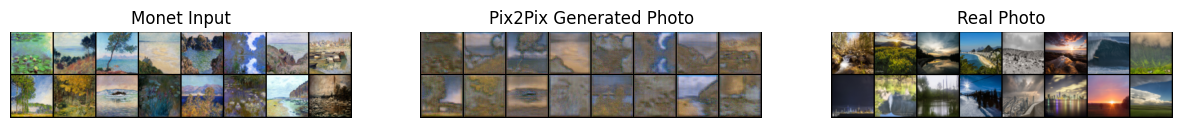

In [32]:
import matplotlib.pyplot as plt
import torchvision

# Get one batch
monet, photo = next(iter(dataloader))

monet = monet.to(device)
fake_photo = G(monet).cpu()

plt.figure(figsize=(15,5))

# Monet Input
plt.subplot(1,3,1)
plt.title("Monet Input")
plt.imshow(torchvision.utils.make_grid(monet.cpu(), normalize=True).permute(1,2,0))
plt.axis("off")

# Generated Photo
plt.subplot(1,3,2)
plt.title("Pix2Pix Generated Photo")
plt.imshow(torchvision.utils.make_grid(fake_photo, normalize=True).permute(1,2,0))
plt.axis("off")

# Real Photo
plt.subplot(1,3,3)
plt.title("Real Photo")
plt.imshow(torchvision.utils.make_grid(photo, normalize=True).permute(1,2,0))
plt.axis("off")

plt.show()